In [9]:
import json
import yaml
from pathlib import Path
import matplotlib.pyplot as plt

In [14]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

raw_dir = Path("..") / config["paths"]["data_raw"]

batches = {}
for batch_file in sorted(raw_dir.glob("*.json")):
    batch_name = batch_file.stem
    with open(batch_file, "r", encoding="utf-8") as f:
        batches[batch_name] = json.load(f)

for name, papers in batches.items():
    print(f"{name} : {len(papers)} papers")



batch_01 : 500 papers
batch_02 : 500 papers
batch_03 : 500 papers
batch_04 : 500 papers


In [15]:
sample = batches["batch_01"][0]
for key, value in sample.items():
    print(f"{key}: {value[:120] if isinstance(value, str) else value}")

id: http://arxiv.org/abs/2401.00622v3
title: Federated Class-Incremental Learning with New-Class Augmented Self-Distillation
abstract: Federated Learning (FL) enables collaborative model training among participants while guaranteeing the privacy of raw da
published: 2024-01-01T00:54:02Z


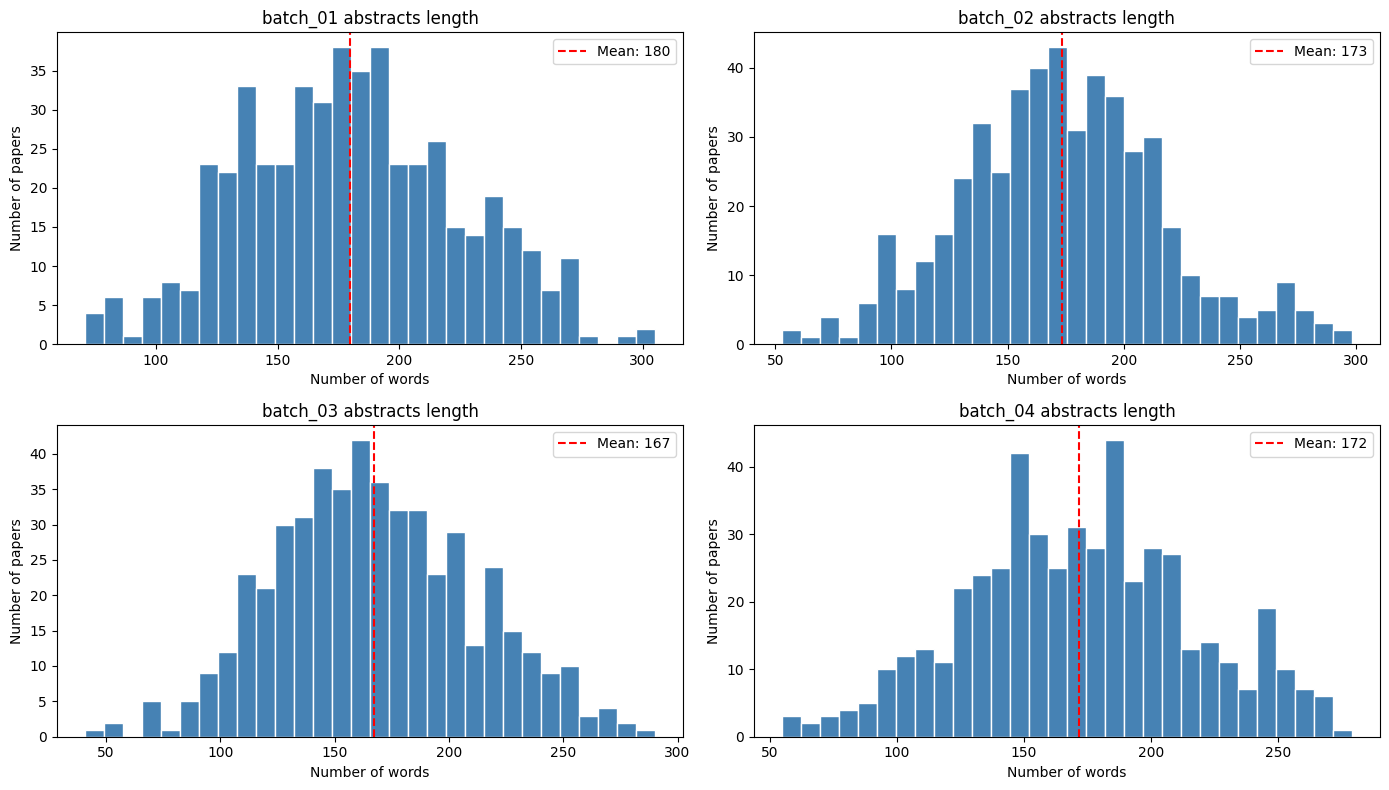

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, papers) in zip(axes.flat, batches.items()):
    lengths = [len(p["abstract"].split()) for p in papers]
    ax.hist(lengths, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{name} abstracts length")
    ax.set_xlabel("Number of words")
    ax.set_ylabel("Number of papers")
    mean_len = sum(lengths) / len(lengths)
    ax.axvline(mean_len, color="red", linestyle="--", label=f"Mean: {mean_len:.0f}")
    ax.legend()

plt.tight_layout()
plt.show()


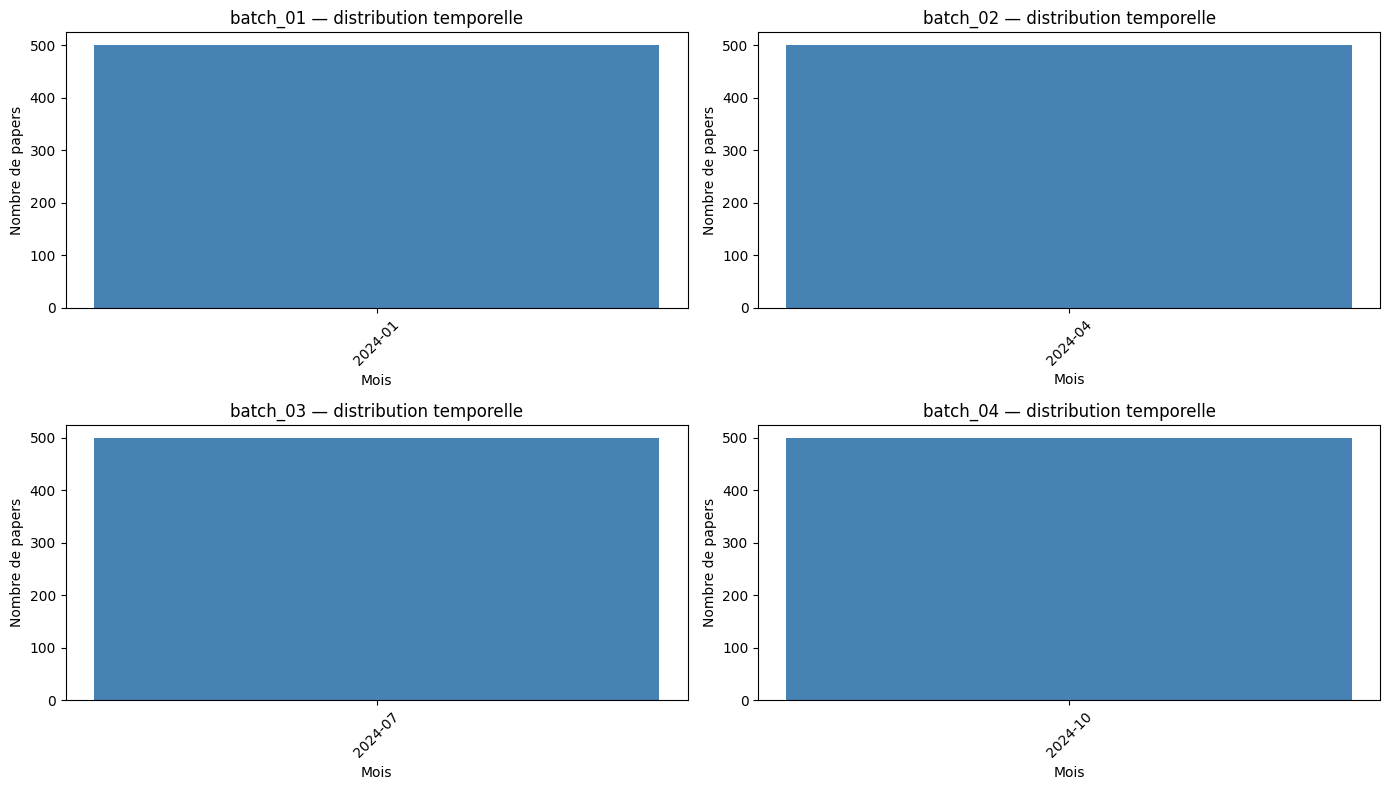

In [20]:
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, papers) in zip(axes.flat, batches.items()):
    months = [p["published"][:7] for p in papers]
    counts = Counter(months)
    sorted_months = sorted(counts.keys())
    ax.bar(sorted_months, [counts[m] for m in sorted_months], color="steelblue")
    ax.set_title(f"{name} — distribution temporelle")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre de papers")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
import random

for name, papers in batches.items():
    print(f"\n{name}")
    sample = random.sample(papers, 5)
    for p in sample:
        print(f"{p['title']}")


batch_01
- Hallucinations in Neural Automatic Speech Recognition: Identifying Errors and Hallucinatory Models
- Beyond Fidelity: Explaining Vulnerability Localization of Learning-based Detectors
- Physio: An LLM-Based Physiotherapy Advisor
- UGGNet: Bridging U-Net and VGG for Advanced Breast Cancer Diagnosis
- Comprehensive Exploration of Synthetic Data Generation: A Survey

batch_02
- PiSSA: Principal Singular Values and Singular Vectors Adaptation of Large Language Models
- Learning Intersections of Halfspaces with Distribution Shift: Improved Algorithms and SQ Lower Bounds
- Classifying Cancer Stage with Open-Source Clinical Large Language Models
- CMULAB: An Open-Source Framework for Training and Deployment of Natural Language Processing Models
- FAIRM: Learning invariant representations for algorithmic fairness and domain generalization with minimax optimality

batch_03
- Are Data Augmentation Methods in Named Entity Recognition Applicable for Uncertainty Estimation?
- Large Scal